## Notebook 1 — Exploratory Data Analysis (EDA)
### Nutrition Intelligence System | NutriScore Classification
---
### Table of Contents
1. [Imports & Setup](#0)
2. [Data Loading & Sampling](#1)
3. [Dataset Overview](#2)
4. [Missing Values Analysis](#3)
5. [Target Variable Analysis](#4)
6. [Feature Analysis](#5)
7. [Features vs NutriScore : Correlation Analysis](#6)
8. [Feature Distributions](#7)
9. [Correlation Heatmap](#8)
10. [Outlier Detection](#9)
11. [Conclusion](#10)

---
<a id='0'></a>
##  0. Imports & Setup

In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('plots',  exist_ok=True)
# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

# NutriScore color palette 
nutriscore_colors = {
    'a': '#038141',  
    'b': '#85BB2F',  
    'c': '#FECB02',  
    'd': '#EE8100',  
    'e': '#E63E11' 

}
target = "nutriscore_grade"
valid_grades = ['a', 'b', 'c', 'd', 'e']
print('Libraries loaded successfully')

Libraries loaded successfully


---
<a id='1'></a>
## 1. Data Loading & Sampling

The original Open Food Facts dataset contains **over 3 million rows** and **209 columns**. We sample **50,000 rows** to keep computation manageable while preserving real-world data quality

In [30]:
"""
df = pd.read_csv("data/en.openfoodfacts.org.products.csv.gz",
                 nrows=50000,low_memory=False,sep="\t",on_bad_lines='skip')

df.to_csv("data/openfoodfacts_sample.csv", index=False)"""


'\ndf = pd.read_csv("data/en.openfoodfacts.org.products.csv.gz",\n                 nrows=50000,low_memory=False,sep="\t",on_bad_lines=\'skip\')\n\ndf.to_csv("data/openfoodfacts_sample.csv", index=False)'

In [3]:
df = pd.read_csv('data/openfoodfacts_sample.csv' , low_memory=False)
print(f'Data loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns')
print(df.columns.tolist())

Data loaded successfully with 50,000 rows and 209 columns
['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'last_modified_by', 'last_updated_t', 'last_updated_datetime', 'product_name', 'abbreviated_product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'packaging_en', 'packaging_text', 'brands', 'brands_tags', 'brands_en', 'categories', 'categories_tags', 'categories_en', 'origins', 'origins_tags', 'origins_en', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_en', 'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags', 'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en', 'serving_size', 'serving_quantity', 'no_nutrition_data', 'additives_n', 'additives', 'additives_tags', 'additives_en', 'n

---
<a id='2'></a>
##  2. Dataset Overview

In [32]:
print("Dataset Info : ")
df.info()
print("Data Types : ")
print(df.dtypes.value_counts())
print("First 5 rows of the dataset : ")
df.head()

Dataset Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 209 entries, code to carbohydrates-total_100g
dtypes: float64(133), int64(4), object(72)
memory usage: 79.7+ MB
Data Types : 
float64    133
object      72
int64        4
Name: count, dtype: int64
First 5 rows of the dataset : 


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g
0,2,http://world-en.openfoodfacts.org/product/0000...,openfoodfacts-contributors,1760861583,2025-10-19T08:13:03Z,1760861586,2025-10-19T08:13:06Z,NaN,1760861586,2025-10-19T08:13:06Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,http://world-en.openfoodfacts.org/product/0000...,openfoodfacts-contributors,1752485388,2025-07-14T09:29:48Z,1752485389,2025-07-14T09:29:49Z,NaN,1752485389,2025-07-14T09:29:49Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,http://world-en.openfoodfacts.org/product/0000...,openfoodfacts-contributors,1768903196,2026-01-20T09:59:56Z,1768903204,2026-01-20T10:00:04Z,NaN,1768903204,2026-01-20T10:00:04Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,http://world-en.openfoodfacts.org/product/0000...,moon-rabbit,1767072228,2025-12-30T05:23:48Z,1767072233,2025-12-30T05:23:53Z,moon-rabbit,1767072233,2025-12-30T05:23:53Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,http://world-en.openfoodfacts.org/product/0000...,moon-rabbit,1760212975,2025-10-11T20:02:55Z,1760218930,2025-10-11T21:42:10Z,ascharao,1760218930,2025-10-11T21:42:10Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
print("Descriptive Statistics : ")
df.describe().round(2)

Descriptive Statistics : 


,code,created_t,last_modified_t,last_updated_t,cities,allergens_en,serving_quantity,additives_n,additives,nutriscore_score,...,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,0.0,0.0,2.849700e+04,22594.00,0.0,19063.00,...,0.0,251.0,272.00,0.0,0.0,0.0,0.0,0.0,0.0,7.00
mean,5.891733e+09,1.629349e+09,1.716483e+09,1.741487e+09,NaN,NaN,2.807549e+05,2.22,NaN,10.69,...,NaN,0.0,0.08,NaN,NaN,NaN,NaN,NaN,NaN,13.48
std,4.630652e+09,8.991266e+07,5.040906e+07,1.691170e+07,NaN,NaN,4.737843e+07,3.14,NaN,10.98,...,NaN,0.0,0.74,NaN,NaN,NaN,NaN,NaN,NaN,16.66
min,2.000000e+00,1.336507e+09,1.465674e+09,1.707490e+09,NaN,NaN,0.000000e+00,0.00,NaN,-17.00,...,NaN,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00
25%,9.060667e+08,1.587641e+09,1.722871e+09,1.734391e+09,NaN,NaN,2.800000e+01,0.00,NaN,1.00,...,NaN,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.59
50%,7.078406e+09,1.632963e+09,1.728043e+09,1.738849e+09,NaN,NaN,5.600000e+01,1.00,NaN,11.00,...,NaN,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,2.00
75%,1.111011e+10,1.713375e+09,1.740252e+09,1.748383e+09,NaN,NaN,1.200000e+02,3.00,NaN,19.00,...,NaN,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,27.16
max,1.120601e+10,1.773300e+09,1.773300e+09,1.773300e+09,NaN,NaN,7.997979e+09,33.00,NaN,54.00,...,NaN,0.0,8.97,NaN,NaN,NaN,NaN,NaN,NaN,36.84


Column Families


,Family,Column Count,Example Columns
0,Product Metadata,23,"code, product_name, abbreviated_product_name"
1,Nutritional Values,121,"energy-kj_100g, energy-kcal_100g, energy_100g"
2,Scores & Grades,9,"no_nutrition_data, nutriscore_score, nutriscor..."
3,Additives & Allergens,11,"ingredients_text, ingredients_tags, ingredient..."
4,Packaging Info,9,"quantity, packaging, packaging_tags"
5,Technical Metadata,16,"url, created_t, created_datetime"


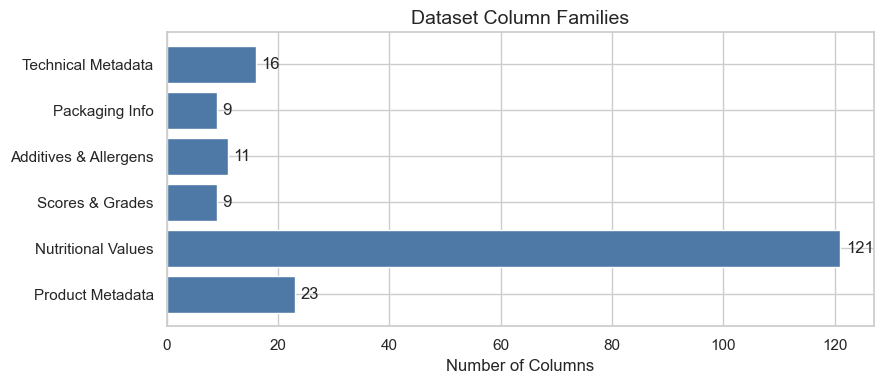

In [34]:
# Column family classification
col_families = {
    'Product Metadata': [c for c in df.columns if any(k in c for k in ['code','name','brand','categ','label','origin','country','store'])],
    'Nutritional Values': [c for c in df.columns if '_100g' in c],
    'Scores & Grades': [c for c in df.columns if any(k in c for k in ['grade','score','nova','nutri'])],
    'Additives & Allergens': [c for c in df.columns if any(k in c for k in ['additive','allergen','ingredient'])],
    'Packaging Info': [c for c in df.columns if any(k in c for k in ['packaging','serving','quantity'])],
    'Technical Metadata': [c for c in df.columns if any(k in c for k in ['url','image','created','modified','owner'])],
}

family_df = pd.DataFrame({
    'Family': list(col_families.keys()),
    'Column Count': [len(v) for v in col_families.values()],
    'Example Columns': [', '.join(v[:3]) for v in col_families.values()]
})


print('Column Families')
display(family_df)

# Visualize
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(family_df['Family'], family_df['Column Count'],
               color='#4E79A7', edgecolor='white', linewidth=1)
ax.bar_label(bars, padding=4)
ax.set_xlabel('Number of Columns')
ax.set_title('Dataset Column Families')
plt.tight_layout()
plt.savefig('plots/column_families.png', dpi=150)
plt.show()

In [35]:
dup_count = df.duplicated().sum()
total = len(df)

dup_percent = (dup_count / total) * 100
print(f"Duplicates: {dup_count} ({dup_percent:.2f}%)")

Duplicates: 0 (0.00%)


---
<a id='3'></a>
## 3. Missing Values Analysis

,Missing Values,Missing (%)
allergens_en,50000,100.0
cities,50000,100.0
additives,50000,100.0
myristic-acid_100g,50000,100.0
palmitic-acid_100g,50000,100.0
...,...,...
created_datetime,0,0.0
last_updated_datetime,0,0.0
created_t,0,0.0
url,0,0.0



Missing Value Summary:


,Missing Category,Column Count
0,No Missing(0%),13
1,Low Missing(0-20%),8
2,High Missing(20-50%),8
3,Very High Missing(50-100%),115
4,All Missing(100%),65


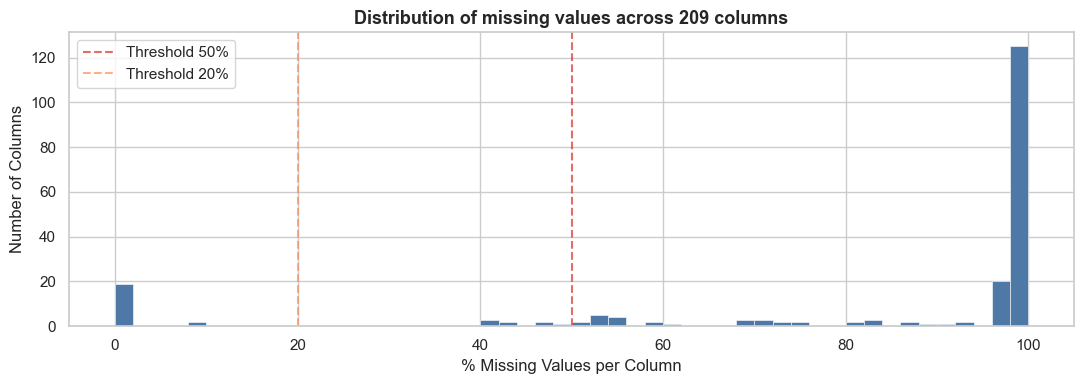

In [ ]:
# compute missing values per column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing (%)': missing_percent
})
zero_missing= missing_df[missing_df['Missing (%)'] == 0].shape[0]
low_missing = missing_df[(missing_df['Missing (%)'] > 0)  & (missing_df['Missing (%)'] <= 20)].shape[0]
high_missing = missing_df[(missing_df['Missing (%)'] > 20) & (missing_df['Missing (%)'] <= 50)].shape[0]
very_high = missing_df[(missing_df['Missing (%)'] > 50) & (missing_df['Missing (%)'] < 100)].shape[0]
all_missing = missing_df[missing_df['Missing (%)'] == 100].shape[0]
missing_summary = pd.DataFrame({
    'Missing Category': ['No Missing(0%)', 'Low Missing(0-20%)', 'High Missing(20-50%)', 'Very High Missing(50-100%)', 'All Missing(100%)'],
    'Column Count': [zero_missing, low_missing, high_missing, very_high, all_missing]
})
display(missing_df)
print("\nMissing Value Summary:")
# tranforù the missing_df into a real table to export it as a csv file
missing_df.reset_index(inplace=True)
missing_df.rename(columns={'index': 'Column'}, inplace=True)
display(missing_summary)
# Distribution of missing values
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(missing_df['Missing (%)'], bins=50, color='#4E79A7', edgecolor='white', linewidth=0.4)
ax.axvline(50, color='#d73027', linestyle='--', alpha=0.7, label='Threshold 50%')
ax.axvline(20, color='#fc8d59', linestyle='--', alpha=0.7, label='Threshold 20%')

ax.set_xlabel('% Missing Values per Column')
ax.set_ylabel('Number of Columns')
ax.set_title(f'Distribution of missing values across {df.shape[1]} columns', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
<a id='4'></a>
##  4. Target Variable Analysis : NutriScore Distribution

Target Variable Distribution (nutriscore_grade):


,Count,Percentage (%)
nutriscore_grade,,
a,3989,7.98
b,2042,4.08
c,3280,6.56
d,4150,8.30
e,5602,11.20
not-applicable,568,1.14
unknown,29601,59.20
NaN,768,1.54



Valid NutriScore Grades (A-E): 19063 products (38.13%)
Invalid/Unknown Grades: 30937 products (61.87%)


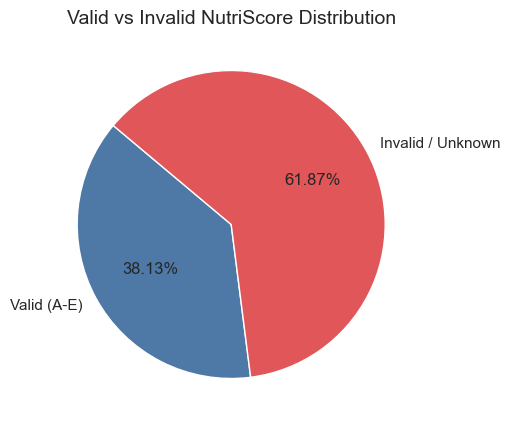

In [6]:
print(f"Target Variable Distribution ({target}):")
target_counts = df[target].value_counts(dropna=False).sort_index()
target_percent = (target_counts / len(df) * 100).round(2)
target_distribution = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_percent
})
display(target_distribution)
valid_counts = df[target].isin(valid_grades).sum()
invalid_counts = len(df) - valid_counts
print(f"\nValid NutriScore Grades (A-E): {valid_counts} products ({(valid_counts/len(df)*100):.2f}%)")
print(f"Invalid/Unknown Grades: {invalid_counts} products ({(invalid_counts/len(df)*100):.2f}%)")
import matplotlib.pyplot as plt

labels = ['Valid (A-E)', 'Invalid / Unknown']
sizes = [valid_counts, invalid_counts]
plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.2f%%', colors=['#4E79A7', '#E15759'], startangle=140)
plt.title('Valid vs Invalid NutriScore Distribution')

plt.show()




In [ ]:
#visualizethe valid vs invalid grades
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df, order=valid_grades + ['invalid'], palette=[nutriscore_colors.get(g, '#999999') for g in valid_grades + ['invalid']])
plt.title('Distribution of NutriScore Grades', fontsize=14, fontweight='bold')
plt.xlabel('NutriScore Grade')
plt.ylabel('Count')

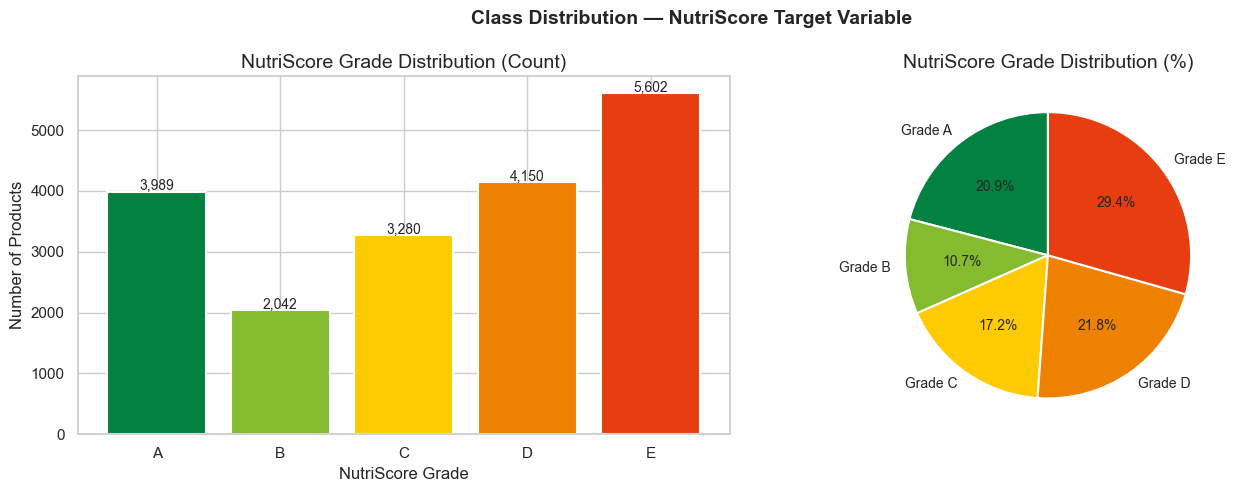


Class Balance Ratio (max/min): 2.74 : Imbalanced


In [38]:
df_valid = df[df[target].isin(valid_grades)].copy()
grade_counts = df_valid[target].value_counts().sort_index()
grade_prcts = (grade_counts / len(df_valid) * 100).round(2)
# Visualize valid grades distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart

colors = [nutriscore_colors[g] for g in grade_counts.index]
axes[0].bar(grade_counts.index.str.upper(), grade_counts.values, color=colors, edgecolor='white', linewidth=1.5 )
axes[0].set_title('NutriScore Grade Distribution (Count)')
axes[0].set_xlabel('NutriScore Grade')
axes[0].set_ylabel('Number of Products')
for i, v in enumerate(grade_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=10)
# Pie chart
axes[1].pie(grade_counts.values, labels=[f'Grade {g.upper()}' for g in grade_counts.index], 
            colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10} , wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('NutriScore Grade Distribution (%)')
plt.suptitle('Class Distribution — NutriScore Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/grade_distribution.png', dpi=150)
plt.show()

ratio = grade_counts.max() / grade_counts.min()
print(f"\nClass Balance Ratio (max/min): {ratio:.2f} : {'Balanced' if ratio < 1.5 else 'Imbalanced'}")


---
<a id='5'></a>
## 5. Feature Analysis





In [39]:
features= df.columns.drop(target)
print(f"Total features (excluding target): {len(features)}")
print("Features types:")
numeric_features = df[features].select_dtypes(include=['int64', 'float64']).columns.to_list()
categorical_features = df[features].select_dtypes(include=['object' , 'category']).columns.to_list()
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Total features (excluding target): 208
Features types:
Numeric features: 137
Categorical features: 71


---
<a id='6'></a>
## 6. Features vs NutriScore : Correlation Analysis

Top 20 Features Most Correlated with NutriScore Grade
  nutriscore_score                    +0.919  (positive)
  energy-from-fat_100g                +0.913  (positive)
  carbohydrates-total_100g            -0.746  (negative)
  nova_group                          +0.458  (positive)
  sucrose_100g                        +0.421  (positive)
  added-sugars_100g                   +0.405  (positive)
  chloride_100g                       -0.307  (negative)
  additives_n                         +0.287  (positive)
  serving_quantity                    -0.276  (negative)
  salt_100g                           +0.269  (positive)
  sodium_100g                         +0.267  (positive)
  energy-kj_100g                      +0.226  (positive)
  energy_100g                         +0.226  (positive)
  environmental_score_score           -0.219  (negative)
  lactose_100g                        +0.219  (positive)
  sugars_100g                         +0.212  (positive)
  energy-kcal_100g                

C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountere

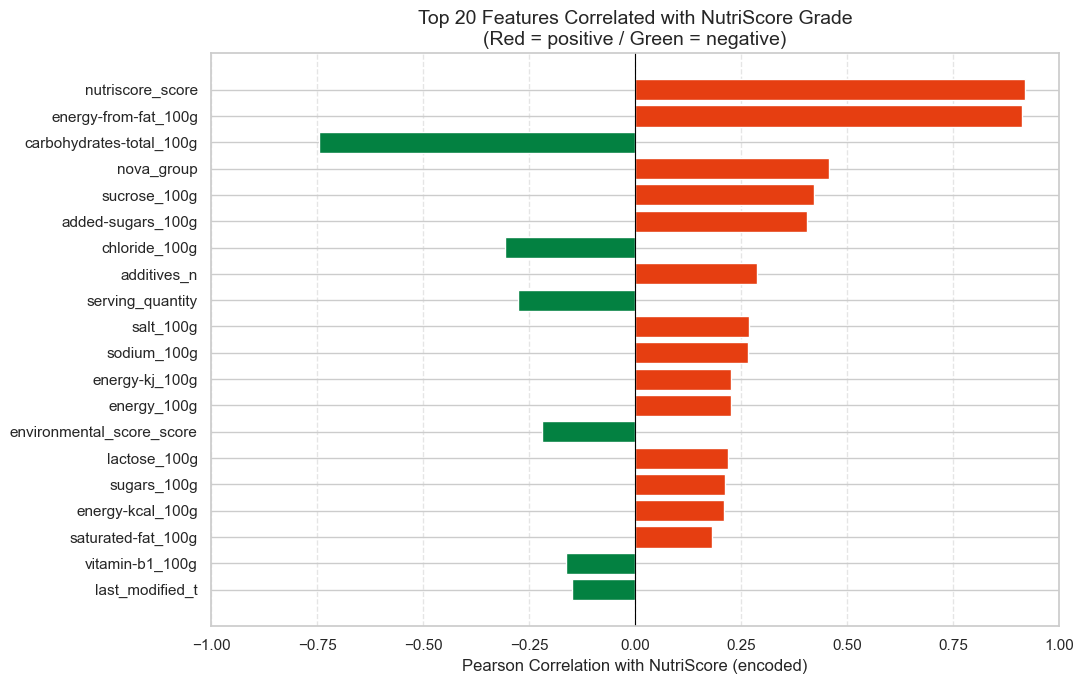

In [40]:
grade_to_int = {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4}
df_valid['nutriscore_encoded'] = df_valid[target].map(grade_to_int)

# Compute correlation of all numeric features with the target
correlation_with_target = (
    df_valid[numeric_features]
    .corrwith(df_valid['nutriscore_encoded'])
    .dropna()
    .sort_values(key=abs, ascending=False)
)

top20 = correlation_with_target.head(20)
top_features = top20.index.tolist()  # used in subsequent sections

print('Top 20 Features Most Correlated with NutriScore Grade')
for feat, val in top20.items():
    direction = 'positive' if val > 0 else 'negative'
    print(f'  {feat:<35} {val:>+.3f}  ({direction})')

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
colors_bar = ['#E63E11' if v > 0 else '#038141' for v in top20.values]
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors_bar[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with NutriScore (encoded)')
ax.set_title('Top 20 Features Correlated with NutriScore Grade\n(Red = positive / Green = negative)')
ax.set_xlim(-1, 1)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plots/correlation_with_target.png', dpi=150)
plt.show()

---
<a id='7'></a>
## 7. Feature Distributions (Top 20 Features)

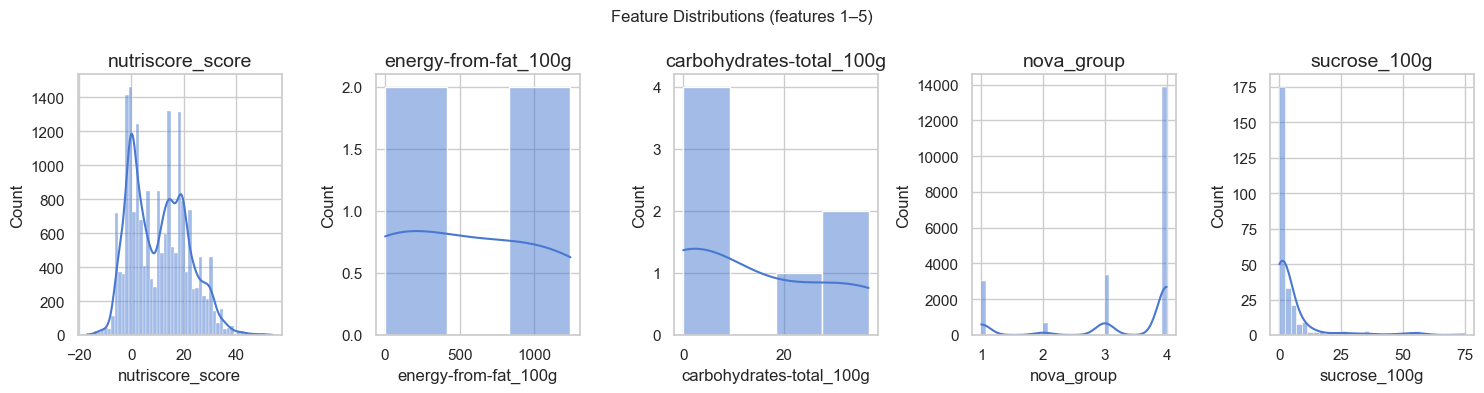

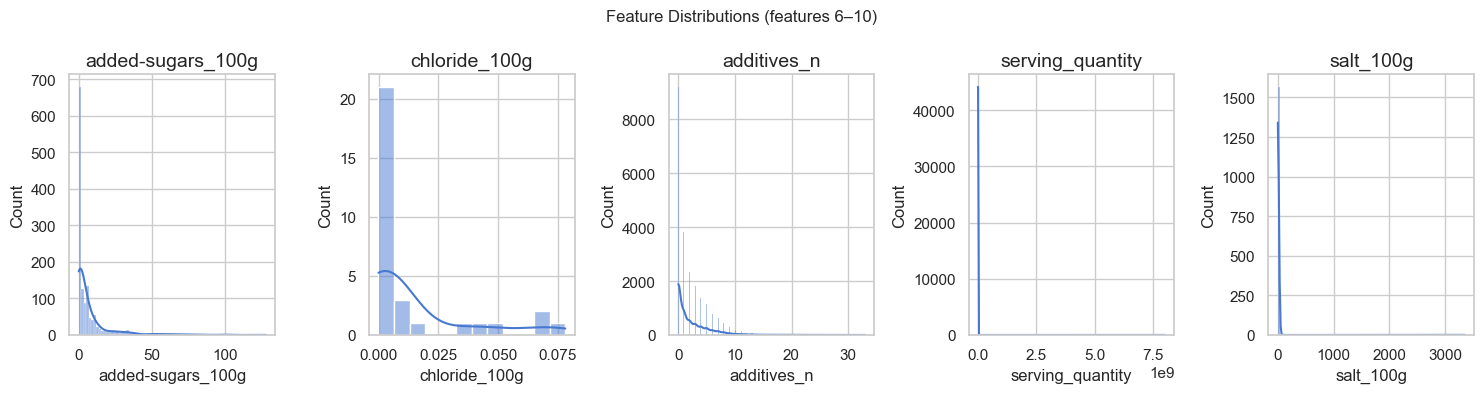

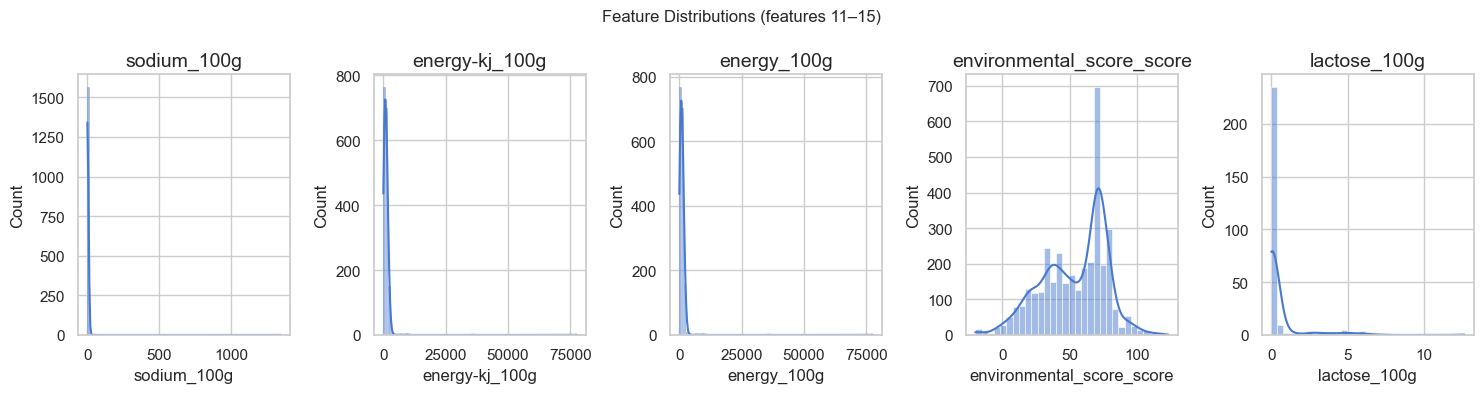

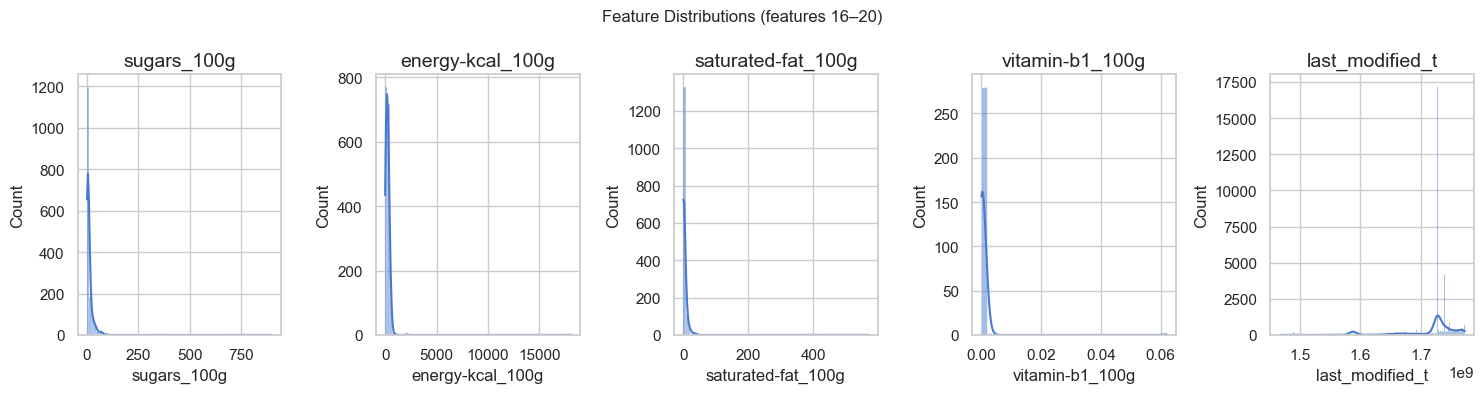

In [41]:
#Distribution of top 20 features
top_features = correlation_with_target.head(20).index.tolist()

# Histogrammes
for i in range(0, len(top_features), 5):
    cols = top_features[i:i+5]
    plt.figure(figsize=(15,4))
    
    for j, col in enumerate(cols):
        plt.subplot(1, len(cols), j+1)
        sns.histplot(df[col], kde=True)
        plt.title(col)
    plt.suptitle(f'Feature Distributions (features {i+1}–{i+len(cols)})', fontsize=12)
    plt.tight_layout()
    plt.savefig('plots/top_20_features_distributions.png', dpi=150)
    plt.show()

---
<a id='8'></a>
## 8. Correlation Heatmap (Top Features)

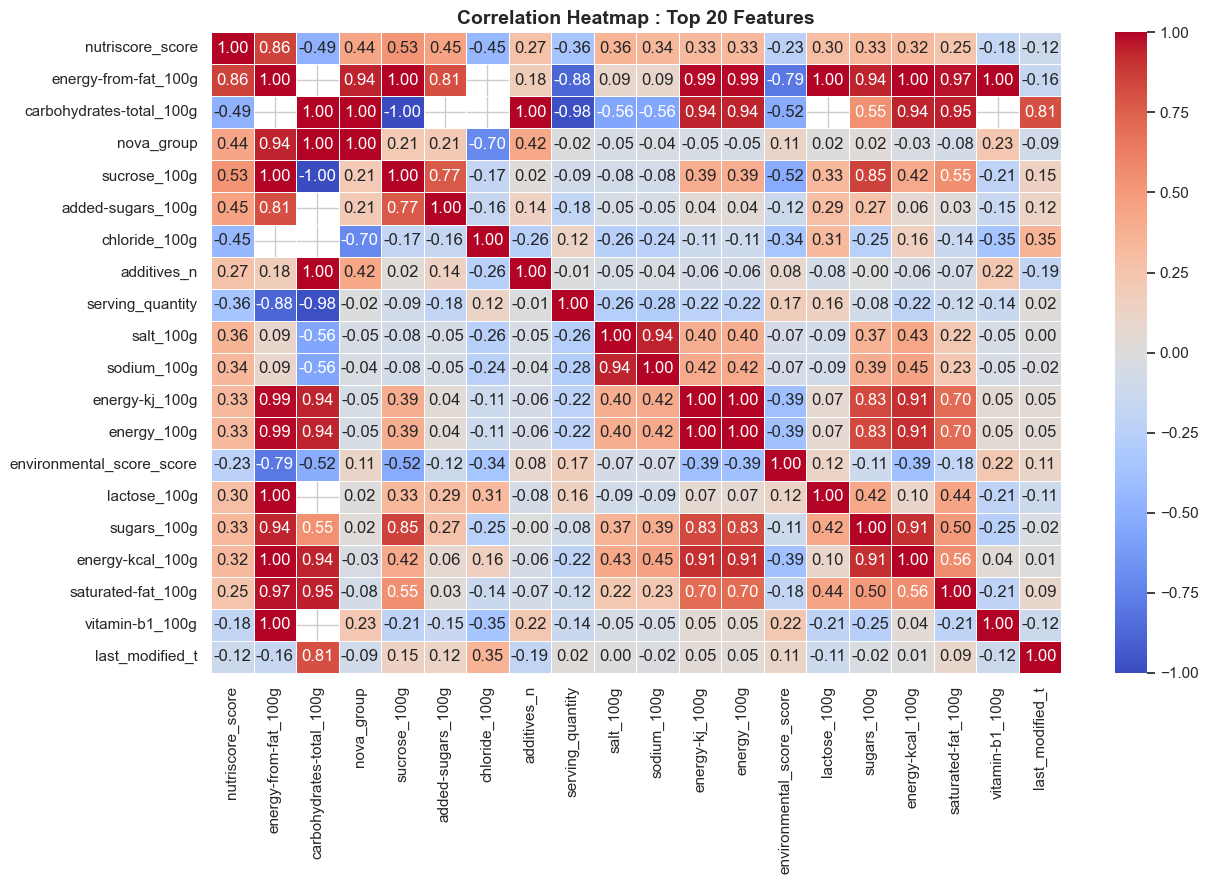

In [42]:
plt.figure(figsize=(13, 9))
sns.heatmap(
    df_valid[top_features].corr(),
    cmap='coolwarm', annot=True, fmt='.2f',
    linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Correlation Heatmap : Top 20 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150)
plt.show()

---
<a id='9'></a>
## 9. Outlier Detection (IQR Method)

In [43]:
outlier_records = []

for feature in top_features:
    col = df_valid[feature].dropna()
    Q1 = col.quantile(0.25)
    Q3  = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((col < lower) | (col > upper)).sum()
    pct = n_outliers / len(col) * 100
    outlier_records.append({
        'Feature': feature,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outliers': n_outliers,
        'Outlier (%)': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_records).sort_values('Outlier (%)', ascending=False)

print('Outlier Summary (IQR Method)')
display(outlier_df[['Feature','Outliers','Outlier (%)','Lower Bound','Upper Bound']])

Outlier Summary (IQR Method)


,Feature,Outliers,Outlier (%),Lower Bound,Upper Bound
19,last_modified_t,6505,34.12,1.705902e+09,1.760752e+09
6,chloride_100g,5,17.24,-1.000000e-02,2.000000e-02
14,lactose_100g,39,16.81,-4.000000e-02,1.600000e-01
3,nova_group,2701,16.04,1.500000e+00,5.500000e+00
17,saturated-fat_100g,152,14.57,-2.250000e+00,3.750000e+00
4,sucrose_100g,24,10.34,-5.920000e+00,1.070000e+01
15,sugars_100g,98,9.19,-9.480000e+00,2.263000e+01
5,added-sugars_100g,81,8.44,-1.103000e+01,1.839000e+01
18,vitamin-b1_100g,17,7.26,-0.000000e+00,0.000000e+00
7,additives_n,1108,6.43,-4.500000e+00,7.500000e+00


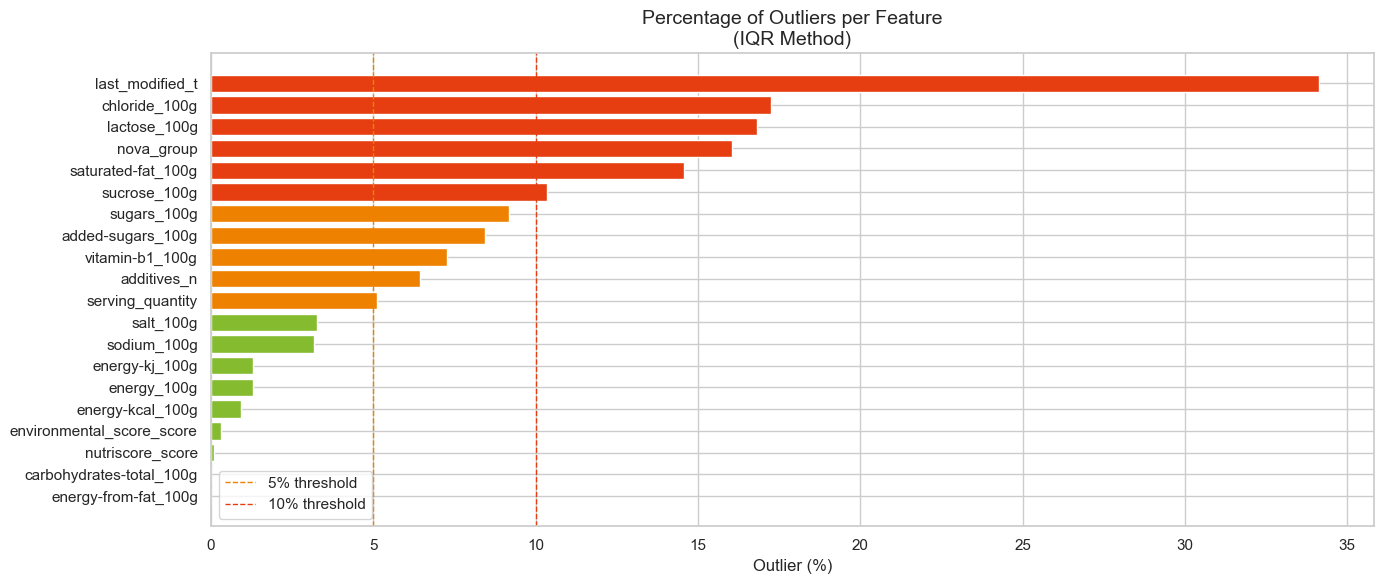

In [44]:
fig = plt.figure(figsize=(14, 6))

# Bar chart: % outliers per feature
bar_colors = ['#E63E11' if v > 10 else '#EE8100' if v > 5 else '#85BB2F' for v in outlier_df['Outlier (%)']]
plt.barh(outlier_df['Feature'][::-1], outlier_df['Outlier (%)'][::-1],
             color=bar_colors[::-1], edgecolor='white')
plt.axvline(5,  color='#EE8100', linestyle='--', linewidth=1, label='5% threshold')
plt.axvline(10, color='#E63E11', linestyle='--', linewidth=1, label='10% threshold')
plt.xlabel('Outlier (%)')
plt.title('Percentage of Outliers per Feature\n(IQR Method)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/outlier_analysis.png', dpi=150)
plt.show()


In [46]:
print("  EDA CONCLUSIONS : NutriScore Decoder")
print("=" * 65)
print("Important Note About this Analysis")
print("=" * 65)
print(f""" This EDA was conducted on a RANDOM SAMPLE of {df.shape[0]:,} rows
 taken from the full Open Food Facts dataset (3M+ products).
 The goal is to explore the data structure, understand its
 problems, and make informed decisions for the Modeling notebook which will load the full dataset directly
""")
print("=" * 65)
print(" 1. DATASET OVERVIEW")
print("=" * 65)
print(f"""We loaded a sample of {df.shape[0]:,} rows and {df.shape[1]} columns from the
 Open Food Facts dataset. The dataset is very heterogeneous
 it contains product metadata (URLs, timestamps, contributor
 names), nutritional values (_100g columns), scores, and
 processing information
 Column breakdown :
   - Numeric features : {len(numeric_features)}
   - Categorical features : {len(categorical_features)}
   - Total features : {df.shape[1] - 1}  (excluding target)

 We didn't find any duplicates in the sample ({df.duplicated().sum()} duplicates) which is expected for a product database where each row
 represents a unique food product
""")
print("=" * 65)
print("2. TARGET VARIABLE : NutriScore Grade")
print("=" * 65)
valid_counts = df[target].isin(valid_grades).sum()
invalid_counts = df.shape[0] - valid_counts
ratio  = grade_counts.max() / grade_counts.min()
print(f""" Out of {df.shape[0]:,} rows in our sample, only {valid_counts:,} have a valid
 NutriScore grade (A to E) which is only {valid_counts/df.shape[0]*100:.1f}% of the data
 The remaining {invalid_counts:,} rows ({invalid_counts/df.shape[0]*100:.1f}%) are labeled
 "unknown", "not-applicable" or NaN and must be removed before training
 Grade distribution (valid rows only) :
""")
for grade, count in grade_counts.sort_index().items():
    pct  = count / valid_counts * 100
    print(f"Grade {grade.upper()} : {count:>5,}  ({pct:5.1f}%)")

print(f"""Class imbalance ratio (max/min) : {ratio:.2f}
   The dataset is IMBALANCED : grade E is the most common
   and grade B is the least common
 DECISION FOR MODELING :
   We will apply stratified sampling (5,000 products per grade)
   to build a perfectly balanced training set. This prevents
   the model from being biased toward the majority classes and ensures it learns to distinguish all grades equally well
   We also keep class_weight='balanced' as an extra safety measure
""")
print("=" * 65)
print("3. MISSING VALUES")
print("=" * 65)
total_missing  = df.isnull().sum().sum()
avg_missing = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100)
cols_100 = (df.isnull().mean() == 1.0).sum()
cols_over50 = (df.isnull().mean() > 0.5).sum()
print(f"""Missing values are a major challenge in this dataset it has 
      so many columns are partially or completely empty 
 Missing value summary :
   - Total missing values : {total_missing:,}
   - Average missing rate : {avg_missing:.1f}% across all columns
   - Columns with 100% NaN : {cols_100}  (completely useless)
   - Columns with > 50% NaN : {cols_over50} 
""")
print("=" * 65)
print("4. FEATURE CORRELATIONS")
print("=" * 65)
top5 = correlation_with_target.head(5)
print(f"""We computed the  correlation between every numeric
 feature and the NutriScore grade (encoded as 0=>A, 4=>E)
 Top 5 most correlated features :
""")
for feat, corr in top5.items():
    print(f"{feat:<35} : {corr:+.4f} ")

print(f"""
 => nutriscore_score has the highest correlation but it is
   EXCLUDED from modeling because it is directly derived from the
   same nutrients we use as features, which would be data leakage
""")
print("=" * 65)
print("5. OUTLIERS")
print("=" * 65)
print(f"""
 The IQR method flagged many apparent outliers in nutritional
 columns but after manual inspection we found that many of them are actually valid values
 and they are not errors or noise for example a biscuit legitimately
 has ~50g of sugar per 100g, a salad has ~2g , this is just the natural variability of food products and not a data quality issue 
 This variance is exactly the signal that seperates the grade A from E  
 """)
print("=" * 62)
print("=> Next step : Notebook 2 — Preprocessing & Modeling")
print("=" * 62)
      


  EDA CONCLUSIONS : NutriScore Decoder
Important Note About this Analysis
 This EDA was conducted on a RANDOM SAMPLE of 50,000 rows
 taken from the full Open Food Facts dataset (3M+ products).
 The goal is to explore the data structure, understand its
 problems, and make informed decisions for the Modeling notebook which will load the full dataset directly

 1. DATASET OVERVIEW
We loaded a sample of 50,000 rows and 209 columns from the
 Open Food Facts dataset. The dataset is very heterogeneous
 it contains product metadata (URLs, timestamps, contributor
 names), nutritional values (_100g columns), scores, and
 processing information
 Column breakdown :
   - Numeric features : 137
   - Categorical features : 71
   - Total features : 208  (excluding target)

 We didn't find any duplicates in the sample (0 duplicates) which is expected for a product database where each row
 represents a unique food product

2. TARGET VARIABLE : NutriScore Grade
 Out of 50,000 rows in our sample, only 19,